In [1]:
print("Hello")

Hello


In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
from backend.app.services.data_services import (
    get_available_indicators,
    get_available_strategies,
    get_strategies_metadata,
    get_available_tickers,
    _read_csv,
    fetch_data_to_df,
    get_indicators_metadata,
    _load_and_resample_data
)
import importlib
import backend.app.core.Strategies as st

import backend.app.services.cache_service as cs
import backend.app.services.data_services as ds
import backend.app.services.plotting_services as ps
import backend.app.services.backtest_services as bs

# importlib.reload(cs)
# importlib.reload(ds)
# importlib.reload(ps)
# importlib.reload(bs)

import asyncio
import pandas as pd
import numpy as np
import vectorbt as vbt

In [19]:
ticker_name = 'RELIANCE INDUSTRIES LTD'
df = await ds._read_csv(ticker_name=ticker_name)
await cs.set_data(df=df, ticker= ticker_name)

{'message': 'Data loaded successfully with key: data:RELIANCE INDUSTRIES LTD'}

In [20]:
cs.get_key_list()
# await cs.delete_data("NIFTY 50")
# ds.get_available_tickers()
# ds.get_available_strategies()

['data:RELIANCE INDUSTRIES LTD']

In [21]:
resolution = "15m"
start_date = "01/12/2024 09:15:00"
end_date = "01/10/2025 09:15:00"

df = await ds._load_and_resample_data(ticker_name, resolution, start_date, end_date)
print(df.shape)
df.head()

(5201, 5)


d:\OneDrive - iitgn.ac.in\Desktop\HedgeOne-Quant\backend\app\services\data_services.py:54: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.



,open,high,low,close,volume
2024-12-02 09:15:00,1288.00,1291.40,1277.05,1278.80,1303678
2024-12-02 09:30:00,1278.70,1285.45,1278.65,1285.10,520330
2024-12-02 09:45:00,1285.10,1287.00,1282.50,1286.00,446780
2024-12-02 10:00:00,1285.85,1288.75,1284.00,1286.70,250166
2024-12-02 10:15:00,1286.50,1295.60,1286.50,1293.95,538794


In [22]:
strategy_name = "EMA Crossover"
params = {"short_window": 9, "long_window": 25}

initial_cash = 100000
fees = 0
slippage = 0

backtest_result = await bs.run_full_backtest(
    ticker_name=ticker_name,
    start_date=start_date,
    end_date=end_date,
    interval=resolution,
    strategy_name=strategy_name,
    params=params,
    initial_cash=initial_cash,
    fees=fees,
    slippage=slippage,
    df = df
)


[BACKTEST] Starting
[DATA] Loading
[STRATEGY] Running

[DEBUG] Weekend trades detected:
            entry_time           exit_time   weekday        date    return
13 2025-02-01 15:00:00 2025-02-03 09:15:00  Saturday  2025-02-01 -0.011186
[TIME SLICE] Running
[BACKTEST] Completed


Hour: {'09:00': {'trades_count': 24, 'total_return_pct': 14.38, 'win_rate_pct': 45.83}, '10:00': {'trades_count': 12, 'total_return_pct': -2.25, 'win_rate_pct': 25.0}, '11:00': {'trades_count': 11, 'total_return_pct': 0.31, 'win_rate_pct': 9.09}, '12:00': {'trades_count': 7, 'total_return_pct': 1.37, 'win_rate_pct': 28.57}, '13:00': {'trades_count': 10, 'total_return_pct': 6.58, 'win_rate_pct': 30.0}, '14:00': {'trades_count': 10, 'total_return_pct': -2.6, 'win_rate_pct': 20.0}, '15:00': {'trades_count': 12, 'total_return_pct': -1.61, 'win_rate_pct': 33.33}}
Days of Week: {'Friday': {'trades_count': 15, 'total_return_pct': 6.59, 'win_rate_pct': 46.67}, 'Monday': {'trades_count': 12, 'total_return_pct': -1.39, 'win_rate_pct': 25.0}, 'Saturday': {'trades_count': 1, 'total_return_pct': -1.12, 'win_rate_pct': 0.0}, 'Thursday': {'trades_count': 20, 'total_return_pct': -0.76, 'win_rate_pct': 20.0}, 'Tuesday': {'trades_count': 16, 'total_return_pct': 10.78, 'win_rate_pct': 50.0}, 'Wednesday':

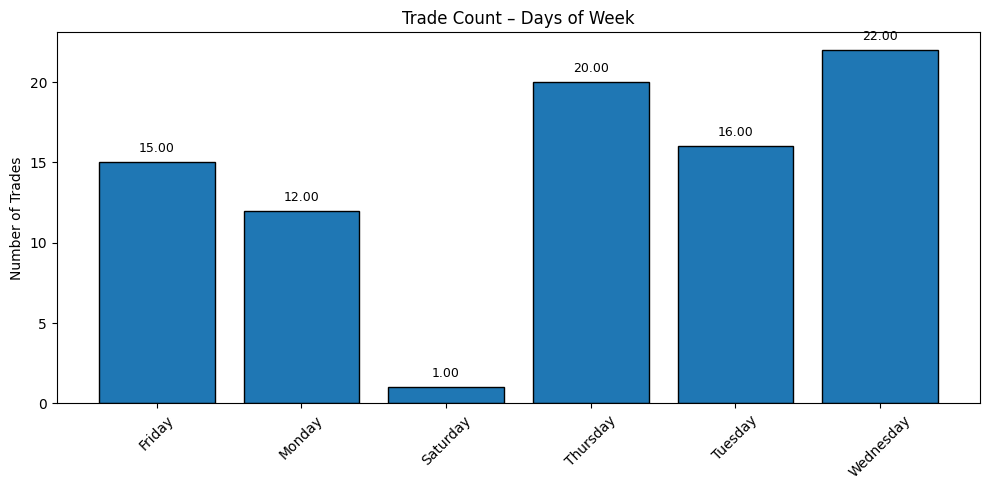

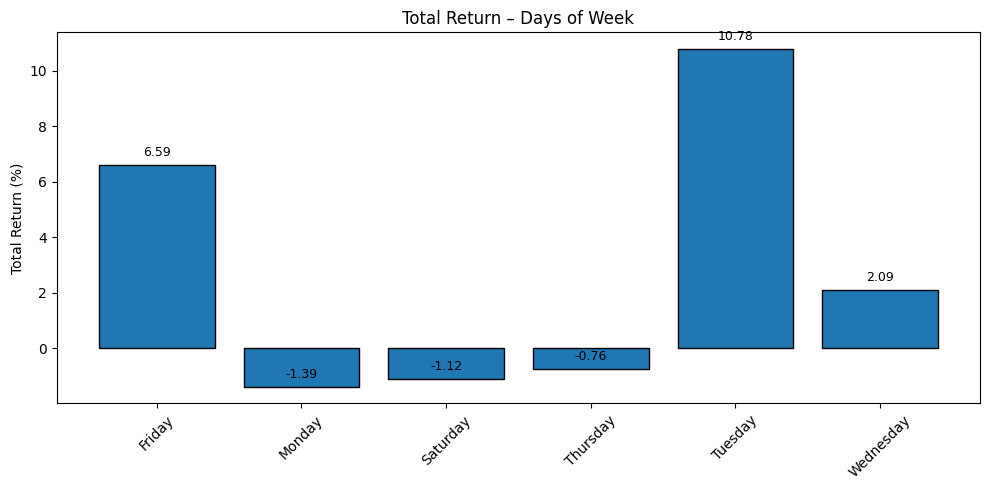

In [23]:
# for k, v in backtest_result["backtest_result"].items():
#     print(f"{k}: {v}")

for unit, data in backtest_result["time_slice_analysis"].items():
    print(f"{unit}: {data}")

plotter = ps.TimeSlicePlotter(backtest_result["time_slice_analysis"])
plotter.plot_trades("Days of Week")
plotter.plot_total_return("Days of Week")
# plotter.days()
# plotter.weeks()
# plotter.months()

In [8]:
stats = backtest_result["backtest_result"]
visualizer = ps.BacktestStatsVisualizer(stats)
# visualizer.plot_table()

In [ ]:
l = ([9]+[10])*2
l

[9, 10, 9, 10]

: 

In [21]:
len(np.arange(10,41))

31

In [8]:
prices = df['close']


ema_fast = vbt.MA.run(prices, [9]*11)
ema_slow = vbt.MA.run(prices, np.arange(25,36))

entries = ema_fast.ma_crossed_above(ema_slow)
exits   = ema_fast.ma_crossed_below(ema_slow)

pf = vbt.Portfolio.from_signals(
    close=prices,
    entries=entries,
    exits=exits,
    init_cash=10000,
    fees=0.0005,
    slippage=0.0,
    freq='30min'
)

In [ ]:
pd.DataFrame(pf.annualized_return()).shape

In [ ]:
pf.stats()

C:\Users\Asus\AppData\Local\Temp\ipykernel_11324\3705677322.py:1: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x000001B25AF157E0>. Pass column to select a single column/group.



Start                               2024-12-02 09:15:00
End                                 2025-10-01 09:15:00
Period                                108 days 08:30:00
Start Value                                     10000.0
End Value                                   6204.165292
Total Return [%]                             -37.958347
Benchmark Return [%]                           7.045668
Max Gross Exposure [%]                            100.0
Total Fees Paid                             3473.056712
Max Drawdown [%]                              38.357121
Max Drawdown Duration                 107 days 12:22:30
Total Trades                                     441.25
Total Closed Trades                              440.75
Total Open Trades                                   0.5
Open Trade PnL                                -1.412349
Win Rate [%]                                  26.030808
Best Trade [%]                                 4.145289
Worst Trade [%]                               -4

: 